**Author**: Felipe Matheus  
**Start Date**: 05/06/2026  
**End Date**: --/--/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: TODO

**Objective**

Build an uncertainty-aware probabilistic predictor of UTS after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [5]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from config.Variables import Variables

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
mdl = Modeling()
varv = Variables()

## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [14]:
# ---- Paths ----
PATH_DATA_RAW = "../../data/raw"
PATH_MODELS = "../../models"
FILE_NAME = "dataset_annealing_tensile-strength.csv"
PROCESS = "annealing_tensile_strength"

# ---- Dataset schema ----
TARGET = "tensile_strength_final"
FEATURES = ["purity", "initial_diameter", "tensile_strength", "temperature", "time"]

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "best_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "best_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of σ²_aleat as fraction of Var(y)
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# 2. Data

In [8]:
# Raw CSV.
df_raw = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME))
df_raw.head()

,material,purity,initial_diameter,grain_size,tensile_strength,temperature,time,grain_size_final,tensile_strength_final,grain_size_ratio,tensile_strength_ratio,is_Cu,yield_strength,yield_strength_final,DOI
0,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,373,60,100.0,1180.0,1.0,0.983333,True,1140.0,1110.0,10.1016/j.matlet.2004.08.014
1,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,473,60,100.0,1150.0,1.0,0.958333,True,1140.0,1050.0,10.1016/j.matlet.2004.08.014
2,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,573,60,150.0,850.0,1.5,0.708333,True,1140.0,640.0,10.1016/j.matlet.2004.08.014
3,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,673,60,250.0,600.0,2.5,0.500000,True,1140.0,370.0,10.1016/j.matlet.2004.08.014
4,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,773,60,300.0,330.0,3.0,0.275000,True,1140.0,200.0,10.1016/j.matlet.2004.08.014


In [13]:
# Cast to float, label material elements, mark rows where ratios are valid.
df_float = proc.df_to_float(
    df_raw, drop_cols=["DOI", "is_Cu", ], ignore_columns=["material"]
)
df_labeled = feng.label_element(df_float).drop_duplicates()
df_with_masks = feng.add_ratio_mask_column(
    feng.add_ratio_mask_column(df_labeled, "grain_size"),
    "tensile_strength",
)
df_with_masks

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(


,material,purity,initial_diameter,grain_size,tensile_strength,temperature,time,grain_size_final,tensile_strength_final,grain_size_ratio,tensile_strength_ratio,yield_strength,yield_strength_final,has_Cu
0,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,373.0,60.0,100.0,1180.0,1.000000,0.983333,1140.0,1110.0,True
1,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,473.0,60.0,100.0,1150.0,1.000000,0.958333,1140.0,1050.0,True
2,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,573.0,60.0,150.0,850.0,1.500000,0.708333,1140.0,640.0,True
3,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,673.0,60.0,250.0,600.0,2.500000,0.500000,1140.0,370.0,True
4,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,773.0,60.0,300.0,330.0,3.000000,0.275000,1140.0,200.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Low-oxygen Cu wire Ø3.00 mm drawn from Ø8 mm (...,99.96,3.0,4400.0,445.0,473.0,30.0,7000.0,254.0,1.590909,0.570787,442.0,98.0,True
88,Low-oxygen Cu wire Ø3.00 mm drawn from Ø8 mm (...,99.96,3.0,4400.0,445.0,523.0,30.0,7800.0,246.0,1.772727,0.552809,442.0,92.0,True
89,Low-oxygen Cu wire Ø3.00 mm drawn from Ø8 mm (...,99.96,3.0,4400.0,445.0,573.0,60.0,11300.0,244.0,2.568182,0.548315,442.0,81.0,True
90,Low-oxygen Cu wire Ø3.00 mm drawn from Ø8 mm (...,99.96,3.0,4400.0,445.0,673.0,60.0,47200.0,239.0,10.727273,0.537079,442.0,64.0,True


In [21]:
# Keep only copper rows and the schema columns.
drop_cols = ["material", "has_Cu", "grain_size_ratio", "iacs_ratio"]
mask_cu = df_with_masks.has_Cu == True
sum(mask_cu)
# df = df_with_masks[mask_cu].drop(columns=drop_cols)
df = df_with_masks[FEATURES + [TARGET]]

# assert df[FEATURES + [TARGET]].isna().sum().sum() == 0, "NaNs in inputs"
# print(f"Dataset: {df.shape}")
# df.head()
df

,purity,initial_diameter,tensile_strength,temperature,time,tensile_strength_final
0,99.99,23.0,1200.0,373.0,60.0,1180.0
1,99.99,23.0,1200.0,473.0,60.0,1150.0
2,99.99,23.0,1200.0,573.0,60.0,850.0
3,99.99,23.0,1200.0,673.0,60.0,600.0
4,99.99,23.0,1200.0,773.0,60.0,330.0
...,...,...,...,...,...,...
87,99.96,3.0,445.0,473.0,30.0,254.0
88,99.96,3.0,445.0,523.0,30.0,246.0
89,99.96,3.0,445.0,573.0,60.0,244.0
90,99.96,3.0,445.0,673.0,60.0,239.0


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [22]:
predictor_a = mdl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(PATH_MODELS, PROCESS, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       8.19 GB / 31.57 GB (25.9%)
Disk Space Avail:   764.22 GB / 932.08 GB (82.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_tensile_strength\model_a"
Train Data Rows:    92
Train Data Columns: 5
Label Column:       tensile_strength_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).

In [23]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-40.781060,root_mean_squared_error,0.129441,21.376239,0.002004,0.007094,2,True,11
1,NeuralNetFastAI_BAG_L1,-45.532369,root_mean_squared_error,0.035330,7.305388,0.035330,7.305388,1,True,6
2,ExtraTreesMSE_BAG_L1,-53.642147,root_mean_squared_error,0.043844,0.355693,0.043844,0.355693,1,True,5
3,XGBoost_BAG_L1,-54.279800,root_mean_squared_error,0.016061,0.835989,0.016061,0.835989,1,True,7
4,CatBoost_BAG_L1,-55.518415,root_mean_squared_error,0.012559,40.576796,0.012559,40.576796,1,True,4
5,NeuralNetTorch_BAG_L1,-56.428188,root_mean_squared_error,0.026139,12.786771,0.026139,12.786771,1,True,8
6,CatBoost_r177_BAG_L1,-57.151663,root_mean_squared_error,0.003999,17.802594,0.003999,17.802594,1,True,10
7,RandomForestMSE_BAG_L1,-59.409404,root_mean_squared_error,0.049907,0.440998,0.049907,0.440998,1,True,3
8,LightGBMLarge_BAG_L1,-60.748670,root_mean_squared_error,0.016692,3.289496,0.016692,3.289496,1,True,9
9,LightGBM_BAG_L1,-73.867441,root_mean_squared_error,0.006871,1.740968,0.006871,1.740968,1,True,2


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [24]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(92,)  any NaN? False


In [25]:
mu_oof

0     1091.368164
1     1003.059082
2      833.771301
3      612.830383
4      539.500977
         ...     
87     332.372040
88     253.476120
89     237.176300
90     281.087158
91     196.159729
Name: tensile_strength_final, Length: 92, dtype: float32

In [26]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = mdl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (10, 92)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1', 'CatBoost_r177_BAG_L1']


In [27]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = mdl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000029  (OK)

Non-zero weights:
  RandomForestMSE_BAG_L1          0.1250
  NeuralNetFastAI_BAG_L1          0.5000
  XGBoost_BAG_L1                  0.1250
  NeuralNetTorch_BAG_L1           0.2500


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [28]:
mu_recomputed, sigma2_epist_oof = mdl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

print("sigma2_epist_oof stats:")
print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
print(f"  median = {np.median(sigma2_epist_oof):.4f}")
print(f"  max    = {sigma2_epist_oof.max():.4f}")

sigma2_epist_oof stats:
  mean   = 979.0101
  median = 286.7436
  max    = 14796.3807


In [29]:
mu_oof

0     1091.368164
1     1003.059082
2      833.771301
3      612.830383
4      539.500977
         ...     
87     332.372040
88     253.476120
89     237.176300
90     281.087158
91     196.159729
Name: tensile_strength_final, Length: 92, dtype: float32

In [30]:
mu_recomputed

array([1091.36816159, 1003.05908498,  833.77128035,  612.83039353,
        539.50099336,  685.83332766,  521.38354941,  748.52682602,
        574.99223679,  729.107913  ,  169.59035533,  140.49173467,
        209.52957809,  216.1317677 ,  284.8203953 ,  275.39433573,
        249.76685773,  266.30580044,  287.70852438,  253.04491446,
        228.89273395,  273.83571949,  261.0061202 ,  261.71767113,
        277.9634695 ,  259.58049402,  259.88009038,  259.44023572,
        244.30872672,  244.67571407,  281.77049365,  466.66913133,
        446.79167869,  433.30645225,  418.45264876,  491.56072121,
        478.60167024,  440.74031539,  445.12461123,  531.12668211,
        513.63099092,  490.10339101,  419.72863233,  266.68367497,
        271.63951093,  258.08421889,  265.62780259,  154.45615271,
        148.41314353,  205.46925181,  190.33010196,  191.67919525,
        236.56110454,  223.56868393,  212.08290175,  210.30879315,
        212.67734864,  206.97594719,  223.15460031,  204.94731

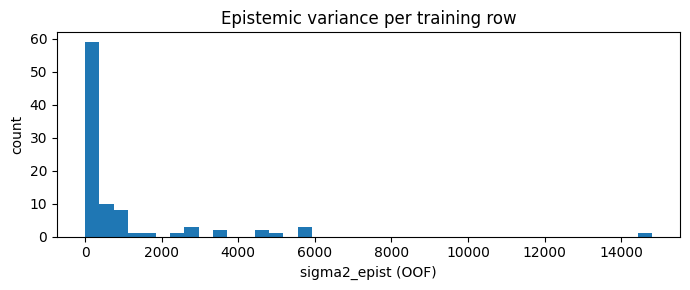

In [31]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

sigma2_epist_oof stats:
  mean   = 1208.9745
  median = 462.1998
  max    = 9254.3398


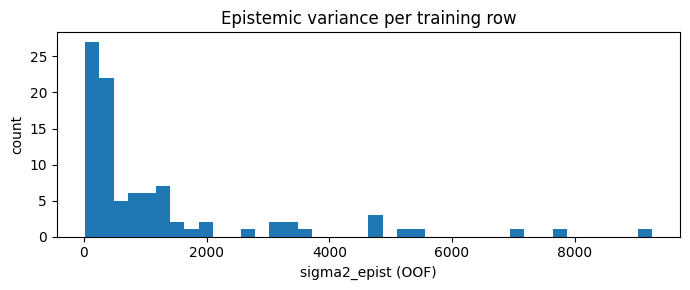

In [32]:
mu_recomputed_lin, sigma2_epist_oof_lin = mdl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

print("sigma2_epist_oof stats:")
print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [33]:
r_tilde_sq, residuals_oof_arr, diag = mdl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 92
  n_truncated          = 48
  pct_truncated        = 52.17391304347826
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 39131.42282005891
  r_tilde_sq_mean      = 1131.126368900207
  r_tilde_sq_median    = 0.0


# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [34]:
predictor_b = mdl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(PATH_MODELS, PROCESS, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.12 GB / 31.57 GB (22.6%)
Disk Space Avail:   764.14 GB / 932.08 GB (82.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_tensile_strength\model_b"
Train Data Rows:    92
Train Data Columns: 5
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label i

In [35]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-9.478729,root_mean_squared_error,0.041571,8.340375,0.001000,0.011447,2,True,13
1,LightGBM_BAG_L1,-9.559930,root_mean_squared_error,0.005120,1.363854,0.005120,1.363854,1,True,2
2,LightGBM_r131_BAG_L1,-9.682647,root_mean_squared_error,0.008240,1.263608,0.008240,1.263608,1,True,12
3,LightGBMXT_BAG_L1,-9.754134,root_mean_squared_error,0.003189,1.226811,0.003189,1.226811,1,True,1
4,NeuralNetFastAI_BAG_L1,-9.911882,root_mean_squared_error,0.035451,6.965074,0.035451,6.965074,1,True,6
5,CatBoost_r177_BAG_L1,-9.983368,root_mean_squared_error,0.007015,1.751931,0.007015,1.751931,1,True,10
6,CatBoost_BAG_L1,-9.994990,root_mean_squared_error,0.004023,1.770789,0.004023,1.770789,1,True,4
7,XGBoost_BAG_L1,-10.210033,root_mean_squared_error,0.010662,0.907656,0.010662,0.907656,1,True,7
8,LightGBMLarge_BAG_L1,-10.234387,root_mean_squared_error,0.002393,1.307748,0.002393,1.307748,1,True,9
9,NeuralNetTorch_BAG_L1,-10.313513,root_mean_squared_error,0.039659,6.665505,0.039659,6.665505,1,True,8


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [36]:
# Build the full OOF predictive distribution.
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = mdl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = mdl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
print(cal_before)

=== Calibration BEFORE recalibration ===
   alpha  empirical_coverage       gap
0   0.50            0.532609  0.032609
1   0.80            0.793478 -0.006522
2   0.90            0.923913  0.023913
3   0.95            0.934783 -0.015217


In [37]:
# Fit a scalar recalibration factor to pull coverage at α=0.9 to nominal.
c_opt = mdl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = mdl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
print(cal_after)

Recalibration scalar c = 1.0902

=== Calibration AFTER recalibration ===
   alpha  empirical_coverage       gap
0   0.50            0.641304  0.141304
1   0.80            0.826087  0.026087
2   0.90            0.923913  0.023913
3   0.95            0.934783 -0.015217


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [38]:
df.head(5)

,purity,initial_diameter,tensile_strength,temperature,time,tensile_strength_final
0,99.99,23.0,1200.0,373.0,60.0,1180.0
1,99.99,23.0,1200.0,473.0,60.0,1150.0
2,99.99,23.0,1200.0,573.0,60.0,850.0
3,99.99,23.0,1200.0,673.0,60.0,600.0
4,99.99,23.0,1200.0,773.0,60.0,330.0


In [39]:
preds = mdl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
)
preds

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total
0,1088.540740,1484.973662,364.319333,2197.849841,46.881231
1,994.859380,1860.857844,364.319333,2644.581102,51.425491
2,822.044266,1418.276329,364.319333,2118.581320,46.028049
3,602.774845,813.586072,364.319333,1399.918355,37.415483
4,431.690011,1517.902915,364.319333,2236.985638,47.296783


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [40]:
artifacts_path = os.path.join(PATH_MODELS, PROCESS, "artifacts.pkl")
os.makedirs(os.path.dirname(artifacts_path), exist_ok=True)

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")

Saved to: ../../models\annealing_tensile_strength\artifacts.pkl
